# 🎭 Twitter Sentiment Analysis
### Multi-Class Classification: Positive | Negative | Neutral

---

**Dataset Features:**
- `text` — Raw tweet content
- `selected_text` — Key sentiment phrase
- `sentiment` — Label: positive / negative / neutral
- `Time of Tweet` — morning / noon / night
- `Age of User`, `Country`, `Population`, `Land Area`, `Density`

**Pipeline:**
`Upload → EDA → Preprocessing → Feature Engineering → Model Training → Evaluation → Prediction`

## 📦 Block 1 — Install & Import Libraries

In [ ]:
# Install any missing packages
!pip install -q scikit-learn pandas numpy matplotlib seaborn wordcloud

# Core
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# ML — Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score

# ML — Models
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# ML — Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Block 2 — Upload Dataset

In [ ]:
from google.colab import files
import zipfile, os

print('📤 Please upload your zip file (archive.zip)...')
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f'\n📦 Extracting: {filename}')

with zipfile.ZipFile(filename, 'r') as z:
    z.extractall('.')

print('\n📁 Extracted files:')
for f in os.listdir('.'):
    if f.endswith('.csv'):
        size = os.path.getsize(f) / (1024*1024)
        print(f'   • {f}  ({size:.2f} MB)')

print('\n✅ Upload complete!')

📤 Please upload your zip file (archive.zip)...


Saving archive.zip to archive.zip

📦 Extracting: archive.zip

📁 Extracted files:
   • train.csv  (4.43 MB)
   • training.1600000.processed.noemoticon.csv  (138.88 MB)
   • testdata.manual.2009.06.14.csv  (0.07 MB)
   • test.csv  (0.45 MB)

✅ Upload complete!


## 📊 Block 3 — Load & Inspect Data

In [ ]:
data = pd.read_csv('train.csv', encoding='ISO-8859-1')

print('━'*55)
print(f'  📐 Shape       : {data.shape[0]:,} rows × {data.shape[1]} columns')
print(f'  🏷️  Columns     : {data.columns.tolist()}')
print(f'  ❓ Null values  :')
for col, n in data.isnull().sum().items():
    if n > 0:
        print(f'        {col}: {n}')
print('━'*55)

print('\n📋 Sentiment Distribution:')
print(data['sentiment'].value_counts().to_string())

print('\n🕐 Time of Tweet Distribution:')
print(data['Time of Tweet'].value_counts().to_string())

print('\n👤 Age Group Distribution:')
print(data['Age of User'].value_counts().to_string())

print('\n🔍 Sample rows:')
data.head(5)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📐 Shape       : 27,481 rows × 10 columns
  🏷️  Columns     : ['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']
  ❓ Null values  :
        text: 1
        selected_text: 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📋 Sentiment Distribution:
sentiment
neutral     11118
positive     8582
negative     7781

🕐 Time of Tweet Distribution:
Time of Tweet
morning    9161
noon       9160
night      9160

👤 Age Group Distribution:
Age of User
0-20      4581
21-30     4580
31-45     4580
46-60     4580
60-70     4580
70-100    4580

🔍 Sample rows:


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


## 📈 Block 4 — Exploratory Data Analysis (EDA)

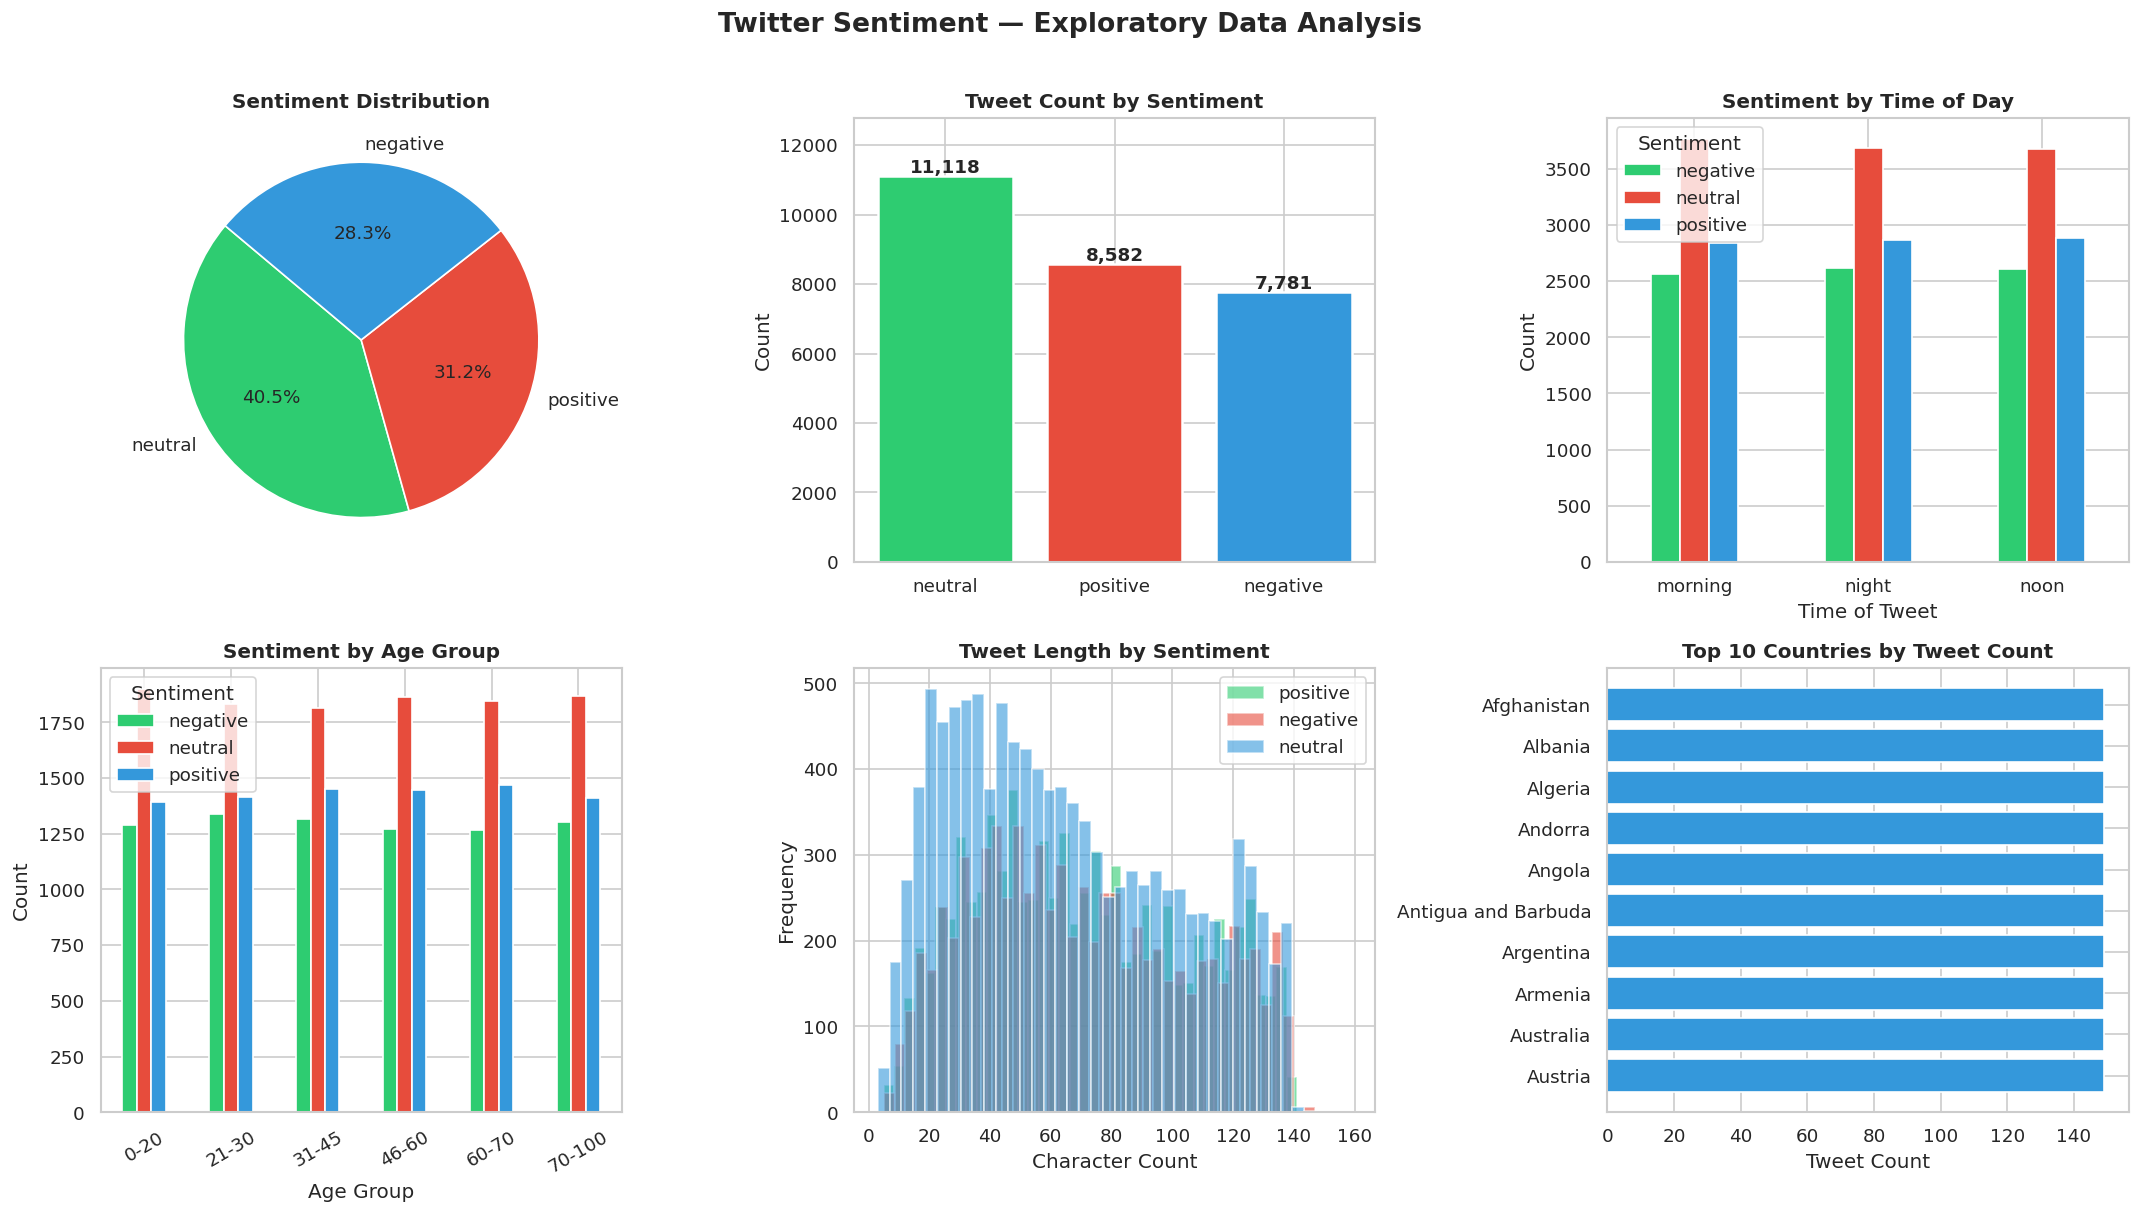

✅ EDA charts generated!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Twitter Sentiment — Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.01)

# ── Plot 1: Sentiment Distribution (Pie) ──
ax = axes[0, 0]
sentiment_counts = data['sentiment'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db']
ax.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
       colors=colors, startangle=140, textprops={'fontsize': 11})
ax.set_title('Sentiment Distribution', fontweight='bold')

# ── Plot 2: Sentiment Bar Chart ──
ax = axes[0, 1]
bars = ax.bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sentiment_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val:,}', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Tweet Count by Sentiment', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, sentiment_counts.max() * 1.15)

# ── Plot 3: Sentiment by Time of Tweet ──
ax = axes[0, 2]
time_sent = data.groupby(['Time of Tweet', 'sentiment']).size().unstack()
time_sent.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Sentiment by Time of Day', fontweight='bold')
ax.set_xlabel('Time of Tweet')
ax.set_ylabel('Count')
ax.legend(title='Sentiment')
ax.tick_params(axis='x', rotation=0)

# ── Plot 4: Sentiment by Age Group ──
ax = axes[1, 0]
age_sent = data.groupby(['Age of User', 'sentiment']).size().unstack().fillna(0)
age_sent.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Sentiment by Age Group', fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Count')
ax.legend(title='Sentiment')
ax.tick_params(axis='x', rotation=30)

# ── Plot 5: Tweet Text Length Distribution ──
ax = axes[1, 1]
data['text_length'] = data['text'].astype(str).apply(len)
for sentiment, color in zip(['positive', 'negative', 'neutral'], colors):
    subset = data[data['sentiment'] == sentiment]['text_length']
    ax.hist(subset, bins=40, alpha=0.6, color=color, label=sentiment)
ax.set_title('Tweet Length by Sentiment', fontweight='bold')
ax.set_xlabel('Character Count')
ax.set_ylabel('Frequency')
ax.legend()

# ── Plot 6: Top 10 Countries ──
ax = axes[1, 2]
top_countries = data['Country'].value_counts().head(10)
ax.barh(top_countries.index[::-1], top_countries.values[::-1], color='#3498db', edgecolor='white')
ax.set_title('Top 10 Countries by Tweet Count', fontweight='bold')
ax.set_xlabel('Tweet Count')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()
print('✅ EDA charts generated!')

## 🧹 Block 6 — Data Cleaning & Preprocessing

In [ ]:
# ── Drop nulls ──
data = data.dropna(subset=['text', 'sentiment']).reset_index(drop=True)

# ── Text cleaning function ──
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()                            # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)     # remove URLs
    text = re.sub(r'@\w+', '', text)               # remove mentions
    text = re.sub(r'#\w+', '', text)               # remove hashtags
    text = re.sub(r'<.*?>', '', text)              # remove HTML tags
    text = re.sub(r"[^a-z\s]", ' ', text)          # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()       # remove extra spaces
    return text

# ── Apply cleaning ──
data['clean_text'] = data['text'].apply(clean_text)

# ── Add useful features ──
data['word_count']    = data['clean_text'].apply(lambda x: len(x.split()))
data['char_count']    = data['clean_text'].apply(len)
data['has_url']       = data['text'].apply(lambda x: int(bool(re.search(r'http\S+', str(x)))))
data['has_mention']   = data['text'].apply(lambda x: int(bool(re.search(r'@\w+', str(x)))))
data['has_hashtag']   = data['text'].apply(lambda x: int(bool(re.search(r'#\w+', str(x)))))

# ── Encode target label ──
le = LabelEncoder()
data['label'] = le.fit_transform(data['sentiment'])
label_map = dict(zip(le.transform(le.classes_), le.classes_))

print('✅ Preprocessing complete!')
print(f'   • Rows after cleaning : {len(data):,}')
print(f'   • Label mapping       : {label_map}')
print(f'   • Avg word count      : {data["word_count"].mean():.1f}')
print(f'   • Avg char count      : {data["char_count"].mean():.1f}')
data[['text', 'clean_text', 'sentiment', 'label', 'word_count']].head(5)

✅ Preprocessing complete!
   • Rows after cleaning : 27,480
   • Label mapping       : {np.int64(0): 'negative', np.int64(1): 'neutral', np.int64(2): 'positive'}
   • Avg word count      : 13.0
   • Avg char count      : 62.6


,text,clean_text,sentiment,label,word_count
0,"I`d have responded, if I were going",i d have responded if i were going,neutral,1,8
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad i will miss you here in san diego,negative,0,10
2,my boss is bullying me...,my boss is bullying me,negative,0,5
3,what interview! leave me alone,what interview leave me alone,negative,0,5
4,"Sons of ****, why couldn`t they put them on t...",sons of why couldn t they put them on the rele...,negative,0,14


## 🔢 Block 7 — Feature Engineering (TF-IDF)

In [ ]:
# ── TF-IDF Vectorization ──
vectorizer = TfidfVectorizer(
    max_features   = 10000,    # top 30k words
    ngram_range    = (1, 2),   # unigrams + bigrams
    sublinear_tf   = True,     # log-scale TF
    min_df         = 2,        # ignore very rare words
    strip_accents  = 'unicode'
)

X = vectorizer.fit_transform(data['clean_text'])
y = data['label']

# ── Train / Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('✅ Feature engineering complete!')
print(f'   • Vocabulary size : {X.shape[1]:,} features')
print(f'   • Training set    : {X_train.shape[0]:,} samples')
print(f'   • Test set        : {X_test.shape[0]:,} samples')
print(f'   • Feature matrix  : {X.shape}')

✅ Feature engineering complete!
   • Vocabulary size : 10,000 features
   • Training set    : 21,984 samples
   • Test set        : 5,496 samples
   • Feature matrix  : (27480, 10000)


## 🤖 Block 8 — Train & Compare Multiple Models

In [ ]:
import time

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Linear SVC'          : LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'Multinomial NB'      : MultinomialNB(alpha=0.1),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=50, random_state=42, n_jobs=-1),
}

results = {}

print('🚀 Training models...\n')
print(f'{"Model":<25} {"Accuracy":>10} {"Time":>10}')
print('─' * 50)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'accuracy': acc, 'y_pred': y_pred, 'time': elapsed}
    print(f'{name:<25} {acc*100:>9.2f}%  {elapsed:>7.1f}s')

best_name = max(results, key=lambda k: results[k]['accuracy'])
print('─' * 50)
print(f'\n🏆 Best model: {best_name} ({results[best_name]["accuracy"]*100:.2f}%)')

🚀 Training models...

Model                       Accuracy       Time
──────────────────────────────────────────────────
Logistic Regression           68.01%      7.0s
Linear SVC                    66.32%      1.4s
Multinomial NB                62.70%      0.0s
Random Forest                 64.74%     16.7s
──────────────────────────────────────────────────

🏆 Best model: Logistic Regression (68.01%)


## 📉 Block 9 — Model Comparison Chart

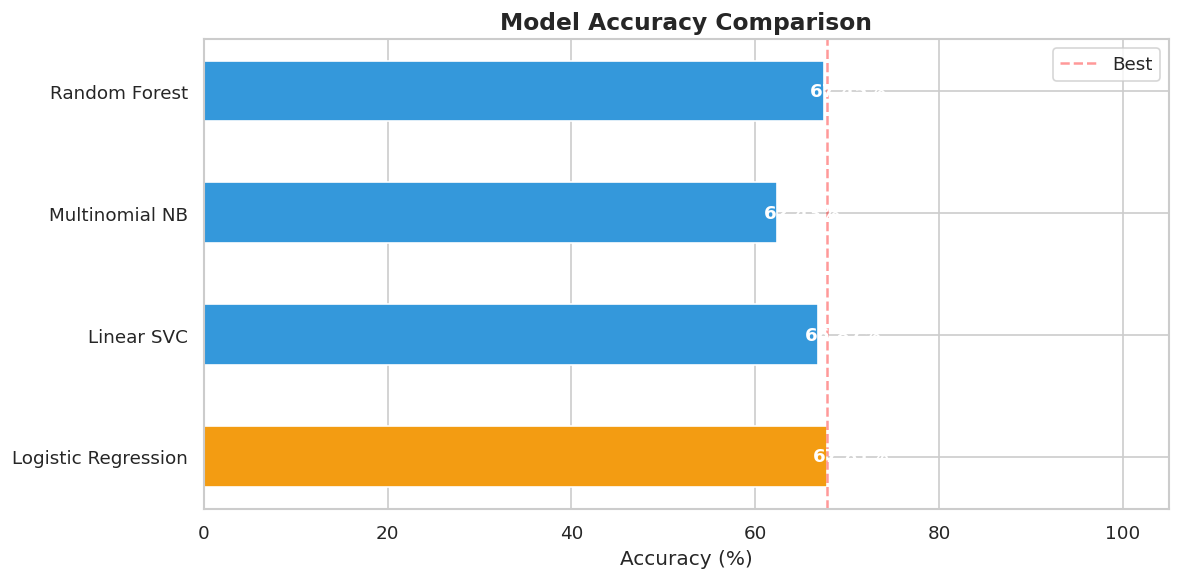

✅ Chart saved!


In [ ]:
names = list(results.keys())
accs  = [results[n]['accuracy'] * 100 for n in names]
colors_bar = ['#f39c12' if n == best_name else '#3498db' for n in names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(names, accs, color=colors_bar, edgecolor='white', height=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() - 1.5, bar.get_y() + bar.get_height()/2,
            f'{acc:.2f}%', va='center', fontweight='bold', color='white', fontsize=11)
ax.set_xlim(0, 105)
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.axvline(x=max(accs), color='red', linestyle='--', alpha=0.4, label='Best')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()
print('✅ Chart saved!')

## 📋 Block 10 — Best Model Detailed Evaluation

🏆 Best Model: Logistic Regression
   Accuracy: 67.81%

📊 Classification Report:
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    negative       0.73      0.58      0.64      1556
     neutral       0.60      0.76      0.67      2223
    positive       0.79      0.66      0.72      1717

    accuracy                           0.68      5496
   macro avg       0.71      0.67      0.68      5496
weighted avg       0.70      0.68      0.68      5496



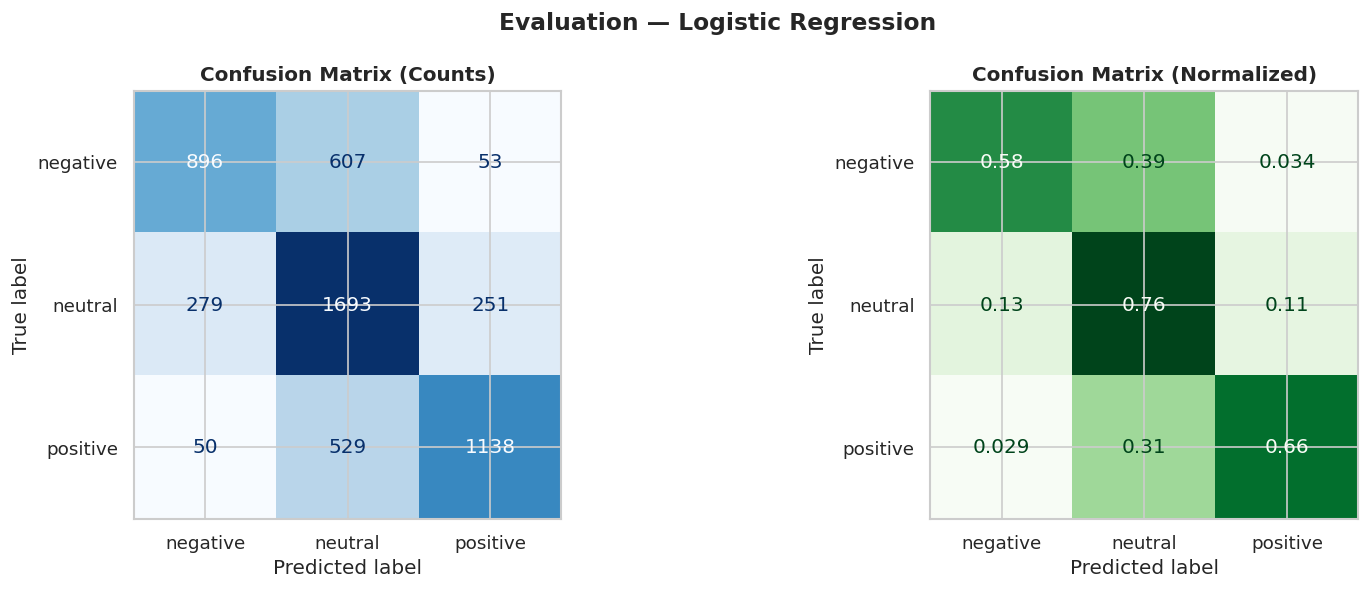

In [ ]:
best_model  = results[best_name]['model']
best_y_pred = results[best_name]['y_pred']
class_names = le.classes_

print(f'🏆 Best Model: {best_name}')
print(f'   Accuracy: {results[best_name]["accuracy"]*100:.2f}%\n')
print('📊 Classification Report:')
print('─' * 55)
print(classification_report(y_test, best_y_pred, target_names=class_names))

# ── Confusion Matrix ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Evaluation — {best_name}', fontsize=14, fontweight='bold')

# Raw counts
cm = confusion_matrix(y_test, best_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

# Normalized
cm_norm = confusion_matrix(y_test, best_y_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

## 🔍 Block 11 — EDA on Errors (Misclassified Tweets)

In [ ]:
# Rebuild test indices
_, test_idx = train_test_split(
    data.index, test_size=0.2, random_state=42, stratify=data['label']
)

test_df = data.loc[test_idx].copy().reset_index(drop=True)
test_df['predicted']   = le.inverse_transform(best_y_pred)
test_df['correct']     = test_df['sentiment'] == test_df['predicted']

errors = test_df[~test_df['correct']]

print(f'❌ Misclassified: {len(errors):,} / {len(test_df):,} ({len(errors)/len(test_df)*100:.1f}%)')
print(f'✅ Correct      : {len(test_df)-len(errors):,} / {len(test_df):,}\n')

print('📊 Error breakdown (true → predicted):')
err_breakdown = errors.groupby(['sentiment', 'predicted']).size().reset_index(name='count')
err_breakdown.columns = ['True Label', 'Predicted As', 'Count']
print(err_breakdown.sort_values('Count', ascending=False).to_string(index=False))

print('\n🔎 Sample misclassified tweets:')
errors[['text', 'sentiment', 'predicted']].head(8)

❌ Misclassified: 1,769 / 5,496 (32.2%)
✅ Correct      : 3,727 / 5,496

📊 Error breakdown (true → predicted):
True Label Predicted As  Count
  negative      neutral    607
  positive      neutral    529
   neutral     negative    279
   neutral     positive    251
  negative     positive     53
  positive     negative     50

🔎 Sample misclassified tweets:


,text,sentiment,predicted
0,Reading and taking notes but undertanding none...,negative,neutral
13,yum. Do you do home delivery,positive,neutral
14,Having a wonderful piece of cake for lunch - w...,positive,neutral
15,"Don`t worry, you`ll get your stamina back soo...",positive,neutral
17,shack idol today(: can`t wait. it`s gonna be f...,neutral,negative
18,"Awww, *hugs* I wish I could help.",negative,positive
19,2 hours after teleconference. but can`t go bac...,negative,neutral
21,Youtube isn`t working...and I wanted to watch ...,negative,neutral


## 🎯 Block 12 — Live Sentiment Predictor

In [ ]:
EMOJI_MAP = {
    'positive': '😊 POSITIVE',
    'negative': '😡 NEGATIVE',
    'neutral' : '😐 NEUTRAL'
}

def predict_sentiment(text):
    """
    Predicts the sentiment of a given tweet text.
    Returns: sentiment label with confidence info.
    """
    cleaned  = clean_text(text)
    vector   = vectorizer.transform([cleaned])
    pred_idx = best_model.predict(vector)[0]
    label    = le.inverse_transform([pred_idx])[0]

    # Confidence via decision function (for LinearSVC / LR)
    confidence = None
    if hasattr(best_model, 'predict_proba'):
        proba      = best_model.predict_proba(vector)[0]
        confidence = max(proba) * 100
    elif hasattr(best_model, 'decision_function'):
        scores     = best_model.decision_function(vector)[0]
        confidence = (max(scores) / (sum(abs(scores)) + 1e-9)) * 100

    print(f'  Input    : "{text}"')
    print(f'  Cleaned  : "{cleaned}"')
    print(f'  Result   : {EMOJI_MAP[label]}')
    if confidence:
        print(f'  Score    : {confidence:.1f}')
    print()
    return label

# ── Test examples ──
test_tweets = [
    "I absolutely love this new update, it's amazing!",
    "This is the worst experience I've ever had. Terrible service.",
    "The meeting is scheduled for tomorrow at 3pm.",
    "I can't believe how bad this movie was, total waste of time!",
    "Just had the most wonderful birthday party, feeling blessed!",
    "The weather today is cloudy with a chance of rain."
]

print('━'*60)
print('          🎭 LIVE SENTIMENT PREDICTIONS')
print('━'*60)
for tweet in test_tweets:
    predict_sentiment(tweet)
print('━'*60)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
          🎭 LIVE SENTIMENT PREDICTIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Input    : "I absolutely love this new update, it's amazing!"
  Cleaned  : "i absolutely love this new update it s amazing"
  Result   : 😊 POSITIVE
  Score    : 96.2

  Input    : "This is the worst experience I've ever had. Terrible service."
  Cleaned  : "this is the worst experience i ve ever had terrible service"
  Result   : 😡 NEGATIVE
  Score    : 81.7

  Input    : "The meeting is scheduled for tomorrow at 3pm."
  Cleaned  : "the meeting is scheduled for tomorrow at pm"
  Result   : 😐 NEUTRAL
  Score    : 58.2

  Input    : "I can't believe how bad this movie was, total waste of time!"
  Cleaned  : "i can t believe how bad this movie was total waste of time"
  Result   : 😡 NEGATIVE
  Score    : 57.3

  Input    : "Just had the most wonderful birthday party, feeling blessed!"
  Cleaned  : "just had the most wonderful bi

## 💾 Block 13 — Save Model for Reuse

In [ ]:
import pickle

# Save model + vectorizer + label encoder
artifacts = {
    'model'      : best_model,
    'vectorizer' : vectorizer,
    'label_encoder': le
}

with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print(f'✅ Model saved as sentiment_model.pkl')
print(f'   Model type : {best_name}')
print(f'   Accuracy   : {results[best_name]["accuracy"]*100:.2f}%')

# Download the model to your device
files.download('sentiment_model.pkl')
print('\n📥 Downloading model to your device...')

## ✅ Block 14 — Summary

In [ ]:
print('━'*60)
print('           📊 PROJECT SUMMARY')
print('━'*60)
print(f'  Dataset       : {len(data):,} tweets')
print(f'  Classes       : {list(le.classes_)}')
print(f'  Features      : TF-IDF (unigrams + bigrams, 30k vocab)')
print(f'  Train/Test    : 80% / 20% (stratified)')
print()
print('  Model Results:')
for name, res in sorted(results.items(), key=lambda x: -x[1]['accuracy']):
    marker = '🏆' if name == best_name else '  '
    print(f'  {marker} {name:<25} {res["accuracy"]*100:.2f}%')
print('━'*60)
print(f'\n  Best Model : {best_name}')
print(f'  Accuracy   : {results[best_name]["accuracy"]*100:.2f}%')
print('━'*60)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
           📊 PROJECT SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dataset       : 27,480 tweets
  Classes       : ['negative', 'neutral', 'positive']
  Features      : TF-IDF (unigrams + bigrams, 30k vocab)
  Train/Test    : 80% / 20% (stratified)

  Model Results:
  🏆 Logistic Regression       67.81%
     Random Forest             67.45%
     Linear SVC                66.87%
     Multinomial NB            62.43%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Best Model : Logistic Regression
  Accuracy   : 67.81%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
